<a href="https://colab.research.google.com/github/awyukt25/SCT_ML_2/blob/main/Customer_Segmentation_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ Customer Segmentation using K-Means Clustering

**Goal:** Group retail-store customers into distinct segments based on their purchase behaviour, so the marketing team knows *who* to target and *how*.

**Dataset:** Kaggle "Mall Customers" (200 customers: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`).

**Type of ML:** *Unsupervised learning* – there is no "correct label"; K-Means discovers groups from the data itself.

### Workflow
1. Load & validate data
2. Exploratory data analysis (EDA)
3. Feature selection (visual **and** quantitative)
4. Scaling
5. Choosing K (Elbow + Silhouette + Davies-Bouldin + Calinski-Harabasz)
6. Train final model & check **stability**
7. Evaluate & visualise clusters
8. Interpret segments → business strategy
9. Extended comparison (adding Age, other algorithms)
10. Predict segment for a new customer & export results

## 0. Imports & Settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib
from itertools import combinations

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42          # reproducible results

## 1. Load & Validate the Data

Run the cell below. If `Mall_Customers.csv` is not found, Colab will ask you to **upload** it
(download it from Kaggle → *Customer Segmentation Tutorial in Python* / *Mall Customers*).

In [2]:
import os

FILE = "Mall_Customers.csv"

if not os.path.exists(FILE):
    try:
        from google.colab import files
        print("Please upload Mall_Customers.csv ...")
        uploaded = files.upload()
        FILE = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("Place Mall_Customers.csv next to this notebook.")

df = pd.read_csv(FILE)

# Some versions of the dataset call the column 'Genre' instead of 'Gender'
df = df.rename(columns={"Genre": "Gender"})
if "CustomerID" not in df.columns:
    df.insert(0, "CustomerID", range(1, len(df) + 1))

print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# ---- Data-quality checks ----
print("Missing values per column:\n", df.isnull().sum(), "\n")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate CustomerIDs:", df["CustomerID"].duplicated().sum())

df.describe().round(2)

Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64 

Duplicate rows: 0
Duplicate CustomerIDs: 0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


## 2. Exploratory Data Analysis

Before clustering, understand each feature's distribution and look for outliers
(K-Means is sensitive to outliers because centroids are means).

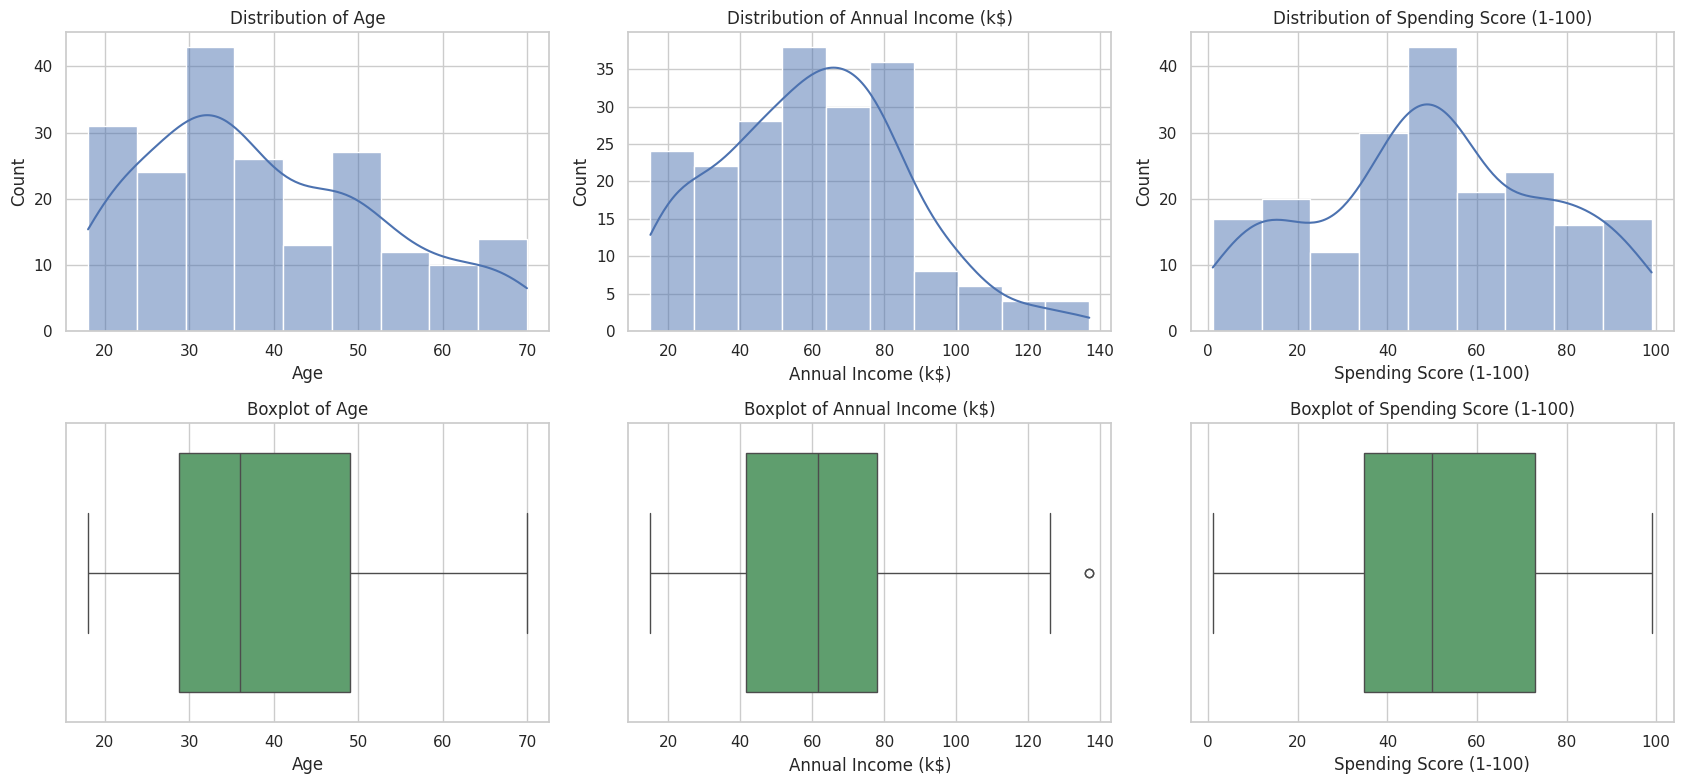

Age                        outliers (IQR rule): 0
Annual Income (k$)         outliers (IQR rule): 2
Spending Score (1-100)     outliers (IQR rule): 0


In [5]:
INC, SPEND, AGE = "Annual Income (k$)", "Spending Score (1-100)", "Age"

fig, axes = plt.subplots(2, 3, figsize=(17, 8))

for ax, col in zip(axes[0], [AGE, INC, SPEND]):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")

for ax, col in zip(axes[1], [AGE, INC, SPEND]):
    sns.boxplot(x=df[col], ax=ax, color="#55A868")
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

# ---- IQR-based outlier count ----
for col in [AGE, INC, SPEND]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col:<26} outliers (IQR rule): {n_out}")

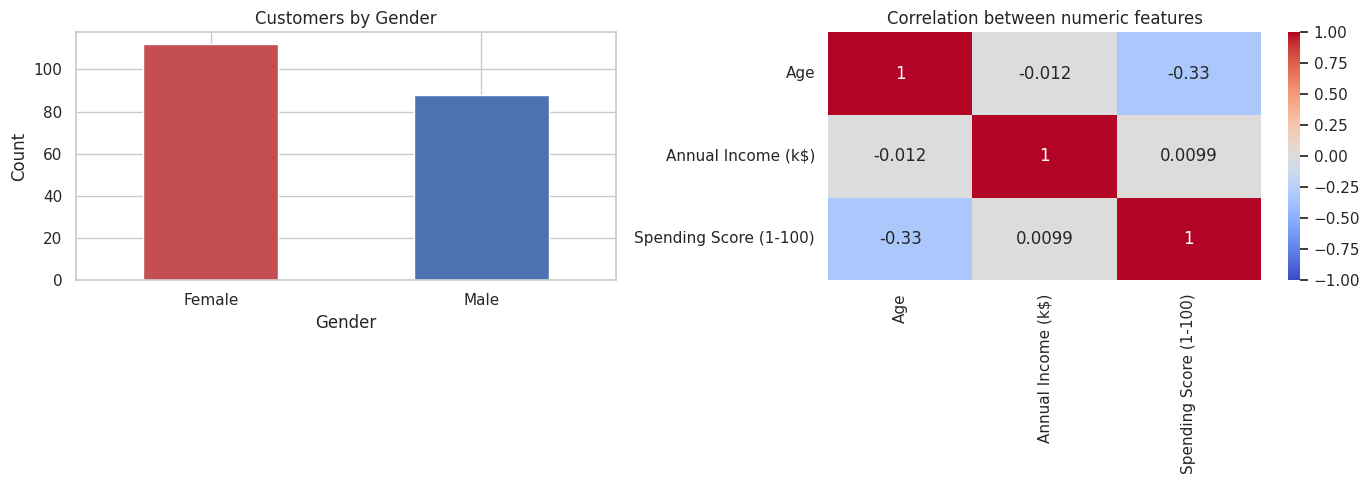

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender split
if "Gender" in df.columns:
    df["Gender"].value_counts().plot(kind="bar", ax=axes[0], color=["#C44E52", "#4C72B0"])
    axes[0].set_title("Customers by Gender")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

# Correlation
sns.heatmap(df[[AGE, INC, SPEND]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation between numeric features")

plt.tight_layout()
plt.show()

## 3. Feature Selection

We use **two lines of evidence**:

1. **Visual** – which pairs of features show natural groupings?
2. **Quantitative** – for every feature combination, what is the best silhouette score K-Means can reach?

> ⚠️ Silhouette scores of models with a *different number of features* are not perfectly comparable, so treat part 2 as supporting evidence, not proof.

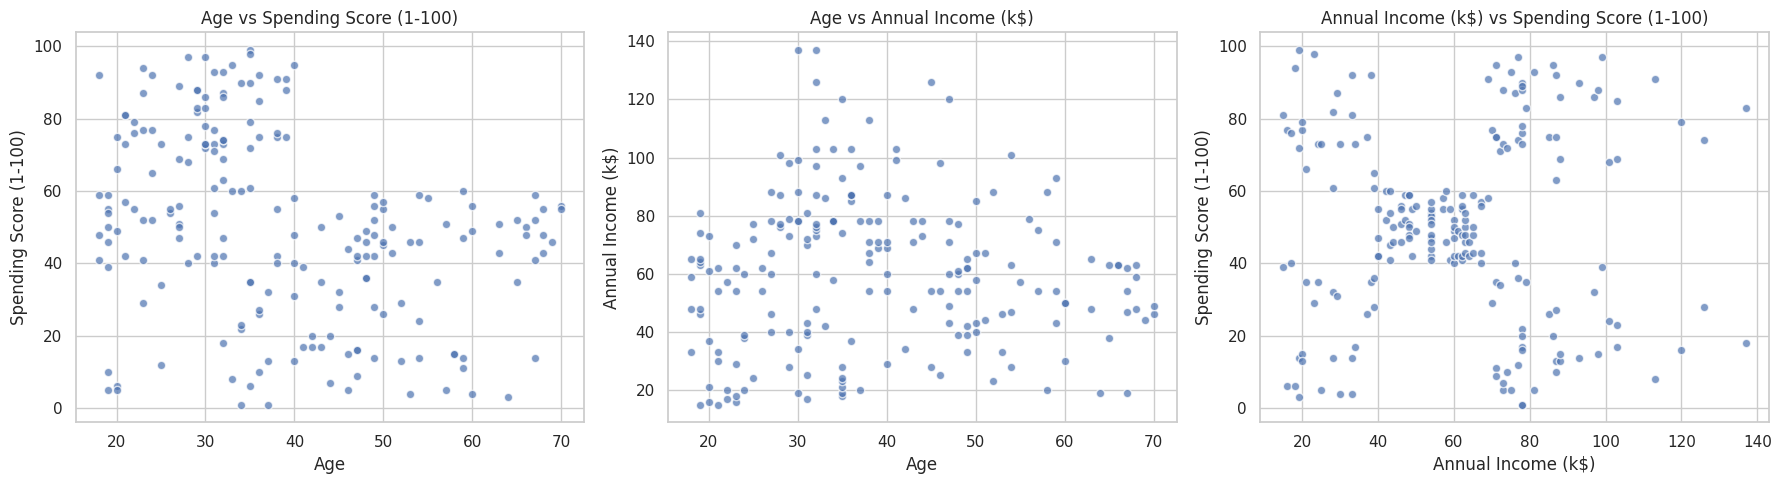

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [(AGE, SPEND), (AGE, INC), (INC, SPEND)]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.7, edgecolor="white")
    ax.set_title(f"{x} vs {y}")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.show()

In [8]:
feature_cols = [AGE, INC, SPEND]
rows = []

for r in (2, 3):
    for combo in combinations(feature_cols, r):
        Xc = StandardScaler().fit_transform(df[list(combo)])
        best_k, best_s = None, -1
        for k in range(2, 9):
            lab = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xc)
            s = silhouette_score(Xc, lab)
            if s > best_s:
                best_k, best_s = k, s
        rows.append({"Features": " + ".join(combo), "Best K": best_k, "Best Silhouette": round(best_s, 3)})

feature_table = pd.DataFrame(rows).sort_values("Best Silhouette", ascending=False).reset_index(drop=True)
feature_table

,Features,Best K,Best Silhouette
0,Annual Income (k$) + Spending Score (1-100),5,0.555
1,Age + Spending Score (1-100),2,0.472
2,Age + Annual Income (k$),3,0.443
3,Age + Annual Income (k$) + Spending Score (1-100),6,0.428


**Reading the table:** the pair *Annual Income + Spending Score* should give the strongest, cleanest separation.
This also makes business sense: how much someone earns and how much they actually spend in the store **is** their purchase behaviour.
`Age` describes *who* the customer is, not *how they buy*, so we use it later only to *profile* the segments.

## 4. Prepare Features + Scaling

K-Means uses **distance**, so features on different scales must be standardised (mean 0, std 1).

- **Model A (primary):** `Annual Income` + `Spending Score`
- **Model B (comparison):** `Age` + `Annual Income` + `Spending Score`

In [9]:
FEATURES_A = [INC, SPEND]
FEATURES_B = [AGE, INC, SPEND]

X_a, X_b = df[FEATURES_A], df[FEATURES_B]

scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a)

scaler_b = StandardScaler()
X_b_scaled = scaler_b.fit_transform(X_b)

print("Model A scaled mean ~", X_a_scaled.mean(axis=0).round(3), "| std ~", X_a_scaled.std(axis=0).round(3))

Model A scaled mean ~ [-0. -0.] | std ~ [1. 1.]


## 5. Choosing K – four metrics, not one

| Metric | Best value |
|---|---|
| **WCSS / Elbow** | "bend" in the curve |
| **Silhouette** | higher (max 1) |
| **Davies-Bouldin** | lower |
| **Calinski-Harabasz** | higher |

The elbow is subjective, so we also detect it automatically (point farthest from the straight line joining the first and last WCSS values).

In [10]:
def find_elbow(ks, values):
    """Point with max distance from the line between first and last point (normalised)."""
    x = np.array(ks, dtype=float)
    y = np.array(values, dtype=float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y - y.min()) / (y.max() - y.min())
    x1, y1, x2, y2 = xn[0], yn[0], xn[-1], yn[-1]
    dist = np.abs((x2 - x1) * (yn - y1) - (y2 - y1) * (xn - x1)) / np.hypot(x2 - x1, y2 - y1)
    return int(x[np.argmax(dist)])


def evaluate_k_range(X, k_values):
    out = []
    for k in k_values:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
        lab = km.fit_predict(X)
        out.append({
            "K": k,
            "WCSS": km.inertia_,
            "Silhouette": silhouette_score(X, lab),
            "Davies-Bouldin": davies_bouldin_score(X, lab),
            "Calinski-Harabasz": calinski_harabasz_score(X, lab),
        })
    return pd.DataFrame(out)


k_range = range(2, 11)
k_results = evaluate_k_range(X_a_scaled, k_range)

elbow_k = find_elbow(k_results["K"], k_results["WCSS"])
best_sil_k = int(k_results.loc[k_results["Silhouette"].idxmax(), "K"])
best_db_k = int(k_results.loc[k_results["Davies-Bouldin"].idxmin(), "K"])
best_ch_k = int(k_results.loc[k_results["Calinski-Harabasz"].idxmax(), "K"])

print(f"Elbow suggests K            = {elbow_k}")
print(f"Best Silhouette K           = {best_sil_k}")
print(f"Best Davies-Bouldin K       = {best_db_k}")
print(f"Best Calinski-Harabasz K    = {best_ch_k}")

k_results.round(3)

Elbow suggests K            = 5
Best Silhouette K           = 5
Best Davies-Bouldin K       = 5
Best Calinski-Harabasz K    = 9


,K,WCSS,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,269.691,0.321,1.267,95.669
1,3,157.704,0.467,0.716,151.335
2,4,108.921,0.494,0.710,174.595
3,5,65.568,0.555,0.572,248.649
4,6,55.057,0.540,0.655,243.088
5,7,44.865,0.528,0.715,254.621
6,8,37.228,0.455,0.760,267.279
7,9,32.392,0.457,0.763,270.948
8,10,29.982,0.443,0.793,260.540


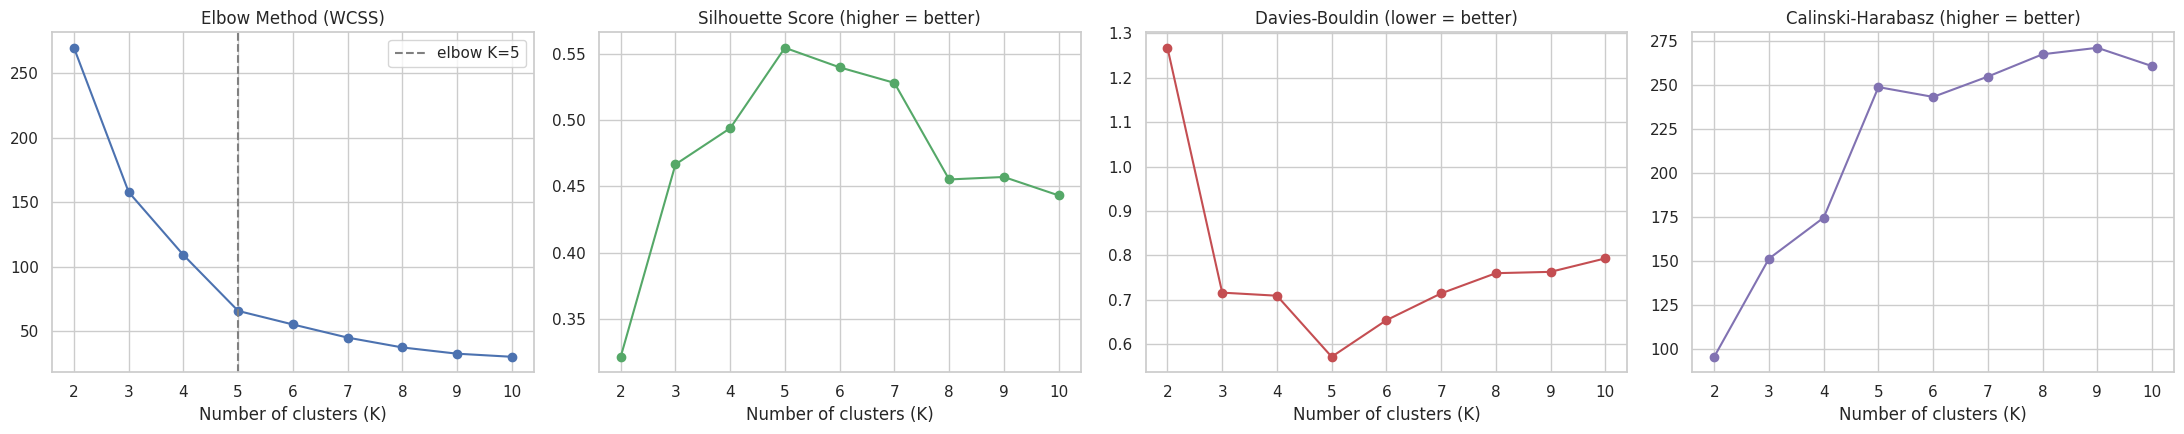

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

plots = [("WCSS", "Elbow Method (WCSS)", "#4C72B0"),
         ("Silhouette", "Silhouette Score (higher = better)", "#55A868"),
         ("Davies-Bouldin", "Davies-Bouldin (lower = better)", "#C44E52"),
         ("Calinski-Harabasz", "Calinski-Harabasz (higher = better)", "#8172B2")]

for ax, (col, title, color) in zip(axes, plots):
    ax.plot(k_results["K"], k_results[col], marker="o", color=color)
    ax.set_title(title)
    ax.set_xlabel("Number of clusters (K)")
    ax.set_xticks(list(k_range))

axes[0].axvline(elbow_k, ls="--", color="gray", label=f"elbow K={elbow_k}")
axes[0].legend()

plt.tight_layout()
plt.show()

## 6. Train the Final Model (Model A: Income + Spending Score)

`K` is taken from the evidence above. If the metrics disagree, change `K` manually and re-run
(you should always justify the final choice in your report).

In [12]:
# Majority vote among the metrics; ties broken in favour of the silhouette score
votes = pd.Series([elbow_k, best_sil_k, best_db_k, best_ch_k]).value_counts()
K = int(votes.index[0]) if votes.iloc[0] > 1 else best_sil_k
print(f"Metric votes:\n{votes}\n\n-> Chosen K = {K}")

kmeans_a = KMeans(n_clusters=K, init="k-means++", n_init=25, random_state=RANDOM_STATE)
labels_a = kmeans_a.fit_predict(X_a_scaled)
df["Cluster"] = labels_a

print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

Metric votes:
5    3
9    1
Name: count, dtype: int64

-> Chosen K = 5

Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


### 6.1 Stability check
A good clustering should not change much when the random initialisation changes.
We re-run K-Means with 20 different seeds and compare each result to the reference using the **Adjusted Rand Index** (1.0 = identical grouping).

In [13]:
aris = []
for seed in range(20):
    lab = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=seed).fit_predict(X_a_scaled)
    aris.append(adjusted_rand_score(labels_a, lab))

print(f"Adjusted Rand Index vs reference over 20 seeds: "
      f"mean = {np.mean(aris):.3f}, min = {np.min(aris):.3f}")
print("Stable clustering ✅" if np.min(aris) > 0.9 else "Some instability – consider a different K or more n_init ⚠️")

Adjusted Rand Index vs reference over 20 seeds: mean = 1.000, min = 1.000
Stable clustering ✅


## 7. Visualise the Clusters

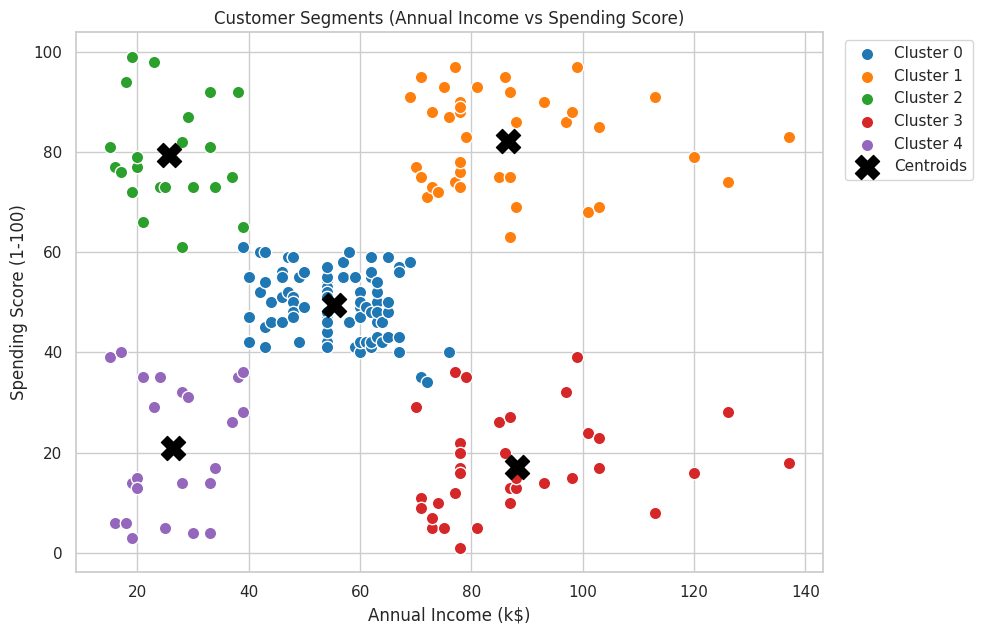

In [14]:
palette = sns.color_palette("tab10", K)

plt.figure(figsize=(10, 6.5))
for c in range(K):
    pts = df[df["Cluster"] == c]
    plt.scatter(pts[INC], pts[SPEND], s=80, color=palette[c], edgecolor="white", label=f"Cluster {c}")

# Centroids converted back to the original scale
centroids = scaler_a.inverse_transform(kmeans_a.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c="black", marker="X", label="Centroids")

plt.title("Customer Segments (Annual Income vs Spending Score)")
plt.xlabel(INC)
plt.ylabel(SPEND)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Evaluate Cluster Quality

The **per-sample silhouette plot** shows if every cluster is well separated – wide bars reaching the right = good;
bars with negative values = points that may sit in the wrong cluster.

Silhouette Score      : 0.555   (closer to 1 is better)
Davies-Bouldin Index  : 0.572   (lower is better)
Calinski-Harabasz     : 248.6   (higher is better)


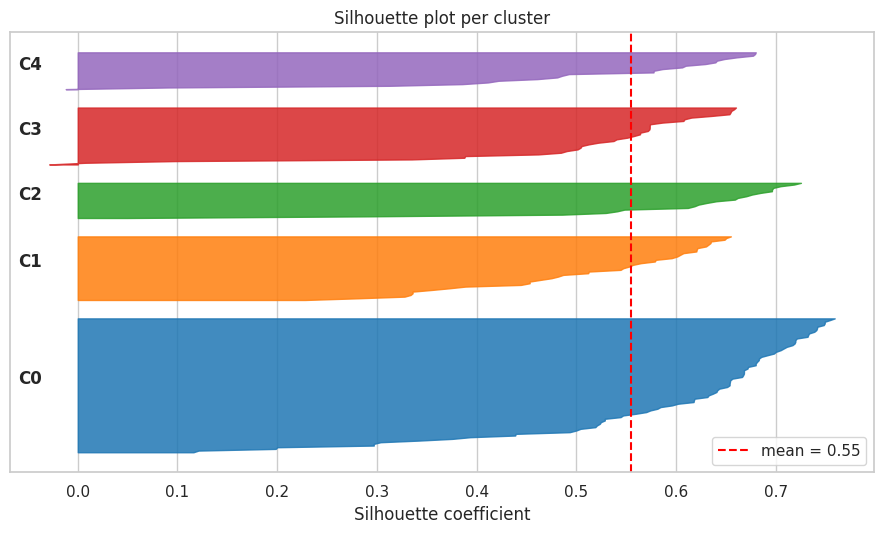

Points with negative silhouette (possibly mis-assigned): 2


In [15]:
score_a = silhouette_score(X_a_scaled, labels_a)
db_a = davies_bouldin_score(X_a_scaled, labels_a)
ch_a = calinski_harabasz_score(X_a_scaled, labels_a)

print(f"Silhouette Score      : {score_a:.3f}   (closer to 1 is better)")
print(f"Davies-Bouldin Index  : {db_a:.3f}   (lower is better)")
print(f"Calinski-Harabasz     : {ch_a:.1f}   (higher is better)")

sample_sil = silhouette_samples(X_a_scaled, labels_a)

fig, ax = plt.subplots(figsize=(9, 5.5))
y_lower = 10
for c in range(K):
    vals = np.sort(sample_sil[labels_a == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=palette[c], alpha=0.85)
    ax.text(-0.06, y_lower + 0.5 * len(vals), f"C{c}", fontweight="bold")
    y_lower = y_upper + 10

ax.axvline(score_a, color="red", ls="--", label=f"mean = {score_a:.2f}")
ax.set_title("Silhouette plot per cluster")
ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

print("Points with negative silhouette (possibly mis-assigned):", int((sample_sil < 0).sum()))

## 9. Interpret the Clusters – the Actual Business Answer

We describe every cluster in plain business terms.

**Naming rule (robust to cluster order):** each cluster's average income and spending score is compared with the overall customer average
in standard deviations. More than +0.5 SD = *High*, below −0.5 SD = *Low*, otherwise *Medium*.
This fixes a weakness of median-based labelling, where the "middle" cluster could be mislabelled as a High/High target group.

In [16]:
profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=(AGE, "mean"),
    Avg_Income=(INC, "mean"),
    Avg_Spending=(SPEND, "mean"),
).round(1)

profile["Share_%"] = (profile["Customers"] / len(df) * 100).round(1)

if "Gender" in df.columns:
    profile["Female_%"] = ((df["Gender"] == "Female").groupby(df["Cluster"]).mean() * 100).round(1)

# ---- Rule-based naming using z-scores relative to all customers ----
inc_mu, inc_sd = df[INC].mean(), df[INC].std()
spd_mu, spd_sd = df[SPEND].mean(), df[SPEND].std()

def level(value, mu, sd, thr=0.5):
    z = (value - mu) / sd
    return "High" if z > thr else ("Low" if z < -thr else "Medium")

NAME_MAP = {
    ("High", "High"):     "Target Customers",
    ("High", "Low"):      "Careful Spenders",
    ("Low", "High"):      "Impulsive Spenders",
    ("Low", "Low"):       "Budget Conscious",
    ("Medium", "Medium"): "Standard Customers",
}

names = {}
for c, row in profile.iterrows():
    inc_lvl = level(row["Avg_Income"], inc_mu, inc_sd)
    spd_lvl = level(row["Avg_Spending"], spd_mu, spd_sd)
    names[c] = NAME_MAP.get((inc_lvl, spd_lvl), f"{inc_lvl} Income / {spd_lvl} Spending")
    profile.loc[c, "Income_Level"] = inc_lvl
    profile.loc[c, "Spending_Level"] = spd_lvl

# Guarantee unique names (in case two clusters fall in the same bucket)
seen = {}
for c in list(names):
    if list(names.values()).count(names[c]) > 1:
        seen[names[c]] = seen.get(names[c], 0) + 1
        names[c] = f"{names[c]} #{seen[names[c]]}"

profile["Segment"] = pd.Series(names)
df["Segment"] = df["Cluster"].map(names)

profile.sort_values("Avg_Income")

,Customers,Avg_Age,Avg_Income,Avg_Spending,Share_%,Female_%,Income_Level,Spending_Level,Segment
Cluster,,,,,,,,,
2,22,25.3,25.7,79.4,11.0,59.1,Low,High,Impulsive Spenders
4,23,45.2,26.3,20.9,11.5,60.9,Low,Low,Budget Conscious
0,81,42.7,55.3,49.5,40.5,59.3,Medium,Medium,Standard Customers
1,39,32.7,86.5,82.1,19.5,53.8,High,High,Target Customers
3,35,41.1,88.2,17.1,17.5,45.7,High,Low,Careful Spenders


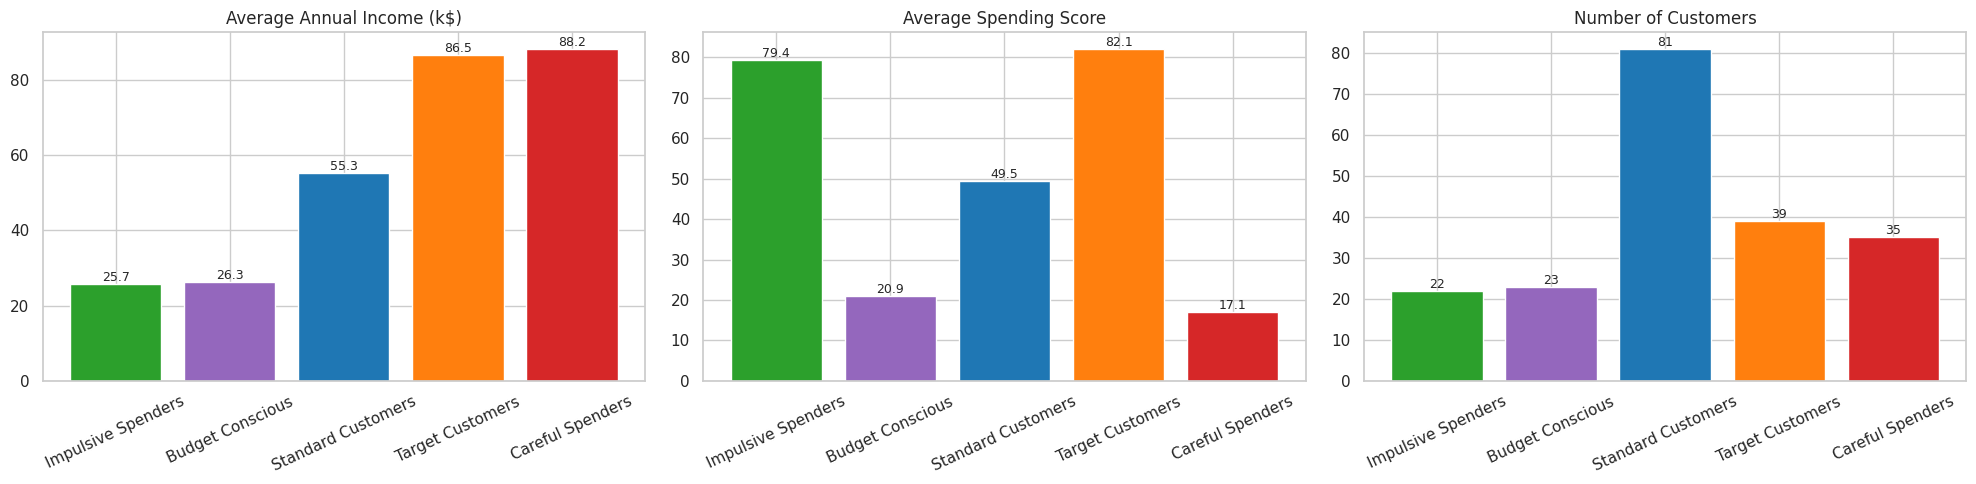

In [17]:
order = profile.sort_values("Avg_Income").index
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (col, title) in zip(axes, [("Avg_Income", "Average Annual Income (k$)"),
                                   ("Avg_Spending", "Average Spending Score"),
                                   ("Customers", "Number of Customers")]):
    ax.bar([names[c] for c in order], profile.loc[order, col], color=[palette[c] for c in order])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)
    for i, v in enumerate(profile.loc[order, col]):
        ax.text(i, v, f"{v:g}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

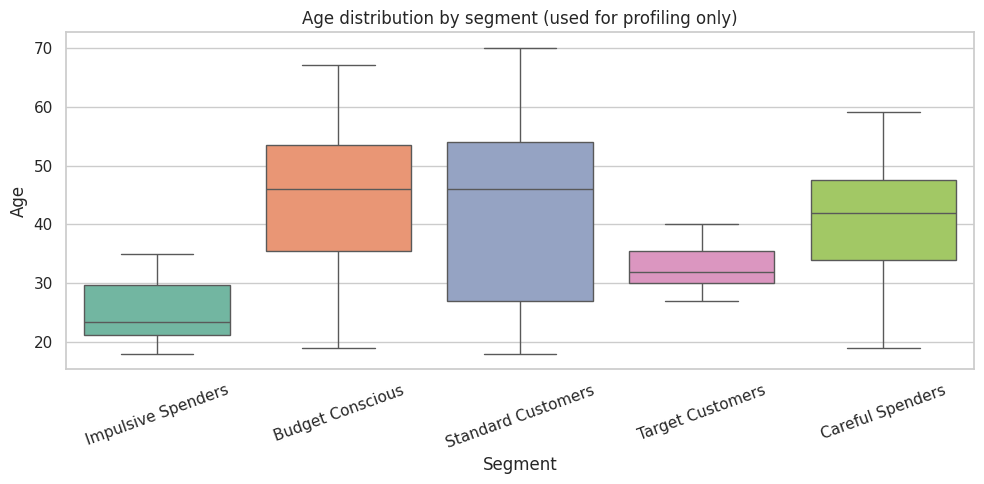

In [18]:
# Age profile of each segment (Age was NOT used to build the clusters – it only describes them)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Segment", y=AGE, order=[names[c] for c in order], palette="Set2")
plt.xticks(rotation=20)
plt.title("Age distribution by segment (used for profiling only)")
plt.tight_layout()
plt.show()

### Marketing playbook per segment

In [19]:
STRATEGY = {
    "Target Customers":   "Top priority. VIP / loyalty programme, early access to new collections, premium upselling.",
    "Careful Spenders":   "Biggest growth opportunity. Quality-focused campaigns, exclusive offers, personalised recommendations to raise their spend.",
    "Impulsive Spenders": "Trend-driven, promotion-responsive. Flash sales, limited editions, EMI / pay-later options.",
    "Budget Conscious":   "Price-sensitive. Discount coupons, bundles, clearance events; low-cost retention.",
    "Standard Customers": "Steady middle group. General campaigns and cross-selling; nudge upward with seasonal offers.",
}

playbook = profile[["Segment", "Customers", "Share_%", "Avg_Income", "Avg_Spending"]].copy()
playbook["Recommended action"] = playbook["Segment"].map(STRATEGY).fillna("Review manually – uncommon profile.")
playbook.sort_values("Avg_Spending", ascending=False).reset_index(drop=True)

,Segment,Customers,Share_%,Avg_Income,Avg_Spending,Recommended action
0,Target Customers,39,19.5,86.5,82.1,"Top priority. VIP / loyalty programme, early a..."
1,Impulsive Spenders,22,11.0,25.7,79.4,"Trend-driven, promotion-responsive. Flash sale..."
2,Standard Customers,81,40.5,55.3,49.5,Steady middle group. General campaigns and cro...
3,Budget Conscious,23,11.5,26.3,20.9,"Price-sensitive. Discount coupons, bundles, cl..."
4,Careful Spenders,35,17.5,88.2,17.1,Biggest growth opportunity. Quality-focused ca...


## 10. Extended Comparison

### 10.1 Does adding Age help? (Model B)
We compare Model A (2 features) with Model B (3 features), both at the chosen K **and** at Model B's own best K.

In [20]:
# Model B at same K
km_b = KMeans(n_clusters=K, init="k-means++", n_init=25, random_state=RANDOM_STATE)
labels_b = km_b.fit_predict(X_b_scaled)
score_b = silhouette_score(X_b_scaled, labels_b)

# Model B at its own best K
k_results_b = evaluate_k_range(X_b_scaled, range(2, 11))
best_k_b = int(k_results_b.loc[k_results_b["Silhouette"].idxmax(), "K"])
best_score_b = k_results_b["Silhouette"].max()

print(f"Model A (Income + Spending)      K={K}: silhouette = {score_a:.3f}")
print(f"Model B (Age + Income + Spending) K={K}: silhouette = {score_b:.3f}")
print(f"Model B at its own best K={best_k_b}:      silhouette = {best_score_b:.3f}")
print(f"\nAgreement between A and B labelings (ARI): {adjusted_rand_score(labels_a, labels_b):.3f}")

if score_a >= score_b and score_a >= best_score_b:
    print("\n✅ Model A gives equal or better-separated clusters – Age adds no useful clustering signal.")
else:
    print("\nModel B separates better on silhouette; check whether the extra complexity is worth it for marketing.")

Model A (Income + Spending)      K=5: silhouette = 0.555
Model B (Age + Income + Spending) K=5: silhouette = 0.417
Model B at its own best K=6:      silhouette = 0.428

Agreement between A and B labelings (ARI): 0.584

✅ Model A gives equal or better-separated clusters – Age adds no useful clustering signal.


In [21]:
fig3d = px.scatter_3d(
    df.assign(Cluster_B=labels_b.astype(str)),
    x=AGE, y=INC, z=SPEND, color="Cluster_B",
    title="Model B – 3D view: Age + Income + Spending Score (interactive)",
    opacity=0.85, height=600,
)
fig3d.update_traces(marker=dict(size=4))
fig3d.show()

### 10.2 Is K-Means the right algorithm? (Model A features)

In [22]:
models = {
    "K-Means":                KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE),
    "Gaussian Mixture":       GaussianMixture(n_components=K, n_init=5, random_state=RANDOM_STATE),
    "Agglomerative (Ward)":   AgglomerativeClustering(n_clusters=K, linkage="ward"),
}

rows = []
for name, model in models.items():
    lab = model.fit_predict(X_a_scaled)
    rows.append({
        "Algorithm": name,
        "Silhouette": round(silhouette_score(X_a_scaled, lab), 3),
        "Davies-Bouldin": round(davies_bouldin_score(X_a_scaled, lab), 3),
        "ARI vs K-Means": round(adjusted_rand_score(labels_a, lab), 3),
    })

pd.DataFrame(rows)

,Algorithm,Silhouette,Davies-Bouldin,ARI vs K-Means
0,K-Means,0.555,0.572,1.000
1,Gaussian Mixture,0.554,0.576,0.956
2,Agglomerative (Ward),0.554,0.578,0.942


A high *ARI vs K-Means* means the other algorithms find essentially the same groups, which supports that the segments are real structure in the data and not an artefact of K-Means.

## 11. Segment a New Customer

A reusable function: give income and spending score → get the segment.

In [23]:
def predict_segment(annual_income_k, spending_score):
    x_new = scaler_a.transform(pd.DataFrame([[annual_income_k, spending_score]], columns=FEATURES_A))
    c = int(kmeans_a.predict(x_new)[0])
    return c, names[c]

for inc, spd in [(20, 80), (85, 90), (90, 15), (55, 50), (25, 10)]:
    c, seg = predict_segment(inc, spd)
    print(f"Income {inc:>3}k$, Spending {spd:>3}  ->  Cluster {c}: {seg}")

Income  20k$, Spending  80  ->  Cluster 2: Impulsive Spenders
Income  85k$, Spending  90  ->  Cluster 1: Target Customers
Income  90k$, Spending  15  ->  Cluster 3: Careful Spenders
Income  55k$, Spending  50  ->  Cluster 0: Standard Customers
Income  25k$, Spending  10  ->  Cluster 4: Budget Conscious


## 12. Save & Download Results

In [24]:
out_cols = ["CustomerID"] + (["Gender"] if "Gender" in df.columns else []) + [AGE, INC, SPEND, "Cluster", "Segment"]
df[out_cols].to_csv("customer_segments.csv", index=False)
playbook.to_csv("segment_playbook.csv", index=False)
joblib.dump({"scaler": scaler_a, "model": kmeans_a, "cluster_names": names, "features": FEATURES_A},
            "kmeans_customer_segmentation.joblib")
print("Saved: customer_segments.csv, segment_playbook.csv, kmeans_customer_segmentation.joblib")

try:
    from google.colab import files
    files.download("customer_segments.csv")
    files.download("segment_playbook.csv")
except ImportError:
    pass

Saved: customer_segments.csv, segment_playbook.csv, kmeans_customer_segmentation.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Conclusion

- **Annual Income** and **Spending Score** together are the clearest signal of purchase behaviour and give well-separated, business-interpretable segments (see the metrics above; the exact values are printed by the code, so they always match your run).
- Four independent metrics (elbow, silhouette, Davies-Bouldin, Calinski-Harabasz) plus a **stability test** (20 random seeds) were used to justify the number of clusters instead of relying on the elbow plot alone.
- **Age** does not improve separation (Section 10.1); it is used only to *describe* segments.
- **Target Customers** (high income, high spending) are the most valuable group to retain and reward.
- **Careful Spenders** (high income, low spending) are the best **growth opportunity** – they have the means, and targeted promotions can move them towards the target segment.
- Other algorithms (GMM, hierarchical) largely agree with K-Means, supporting the reliability of the segmentation.

### Limitations
- Only 200 customers and a synthetic-style dataset – real retail data would include transaction history (RFM: Recency, Frequency, Monetary).
- K-Means assumes roughly round clusters of similar size and is sensitive to outliers.
- Segments are a snapshot; re-run periodically as behaviour changes.